In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
df = pd.read_csv("Superstore.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Shape: (9994, 21)

Columns:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

Data Types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [8]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [9]:
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [10]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [11]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (9994, 21)


In [12]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [13]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month_Name"] = df["Order Date"].dt.month_name()

In [14]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))

Total Sales: 2297200.86
Total Profit: 286397.02


In [15]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

print(category_sales)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


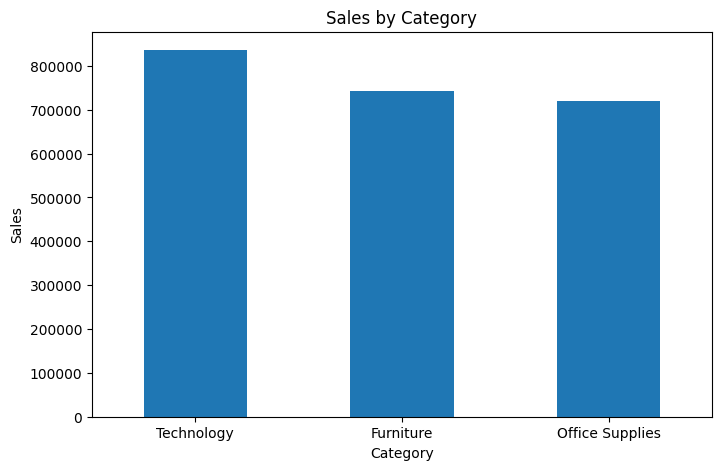

In [16]:
plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)

plt.show()

In [17]:
category_profit = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

print(category_profit)

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


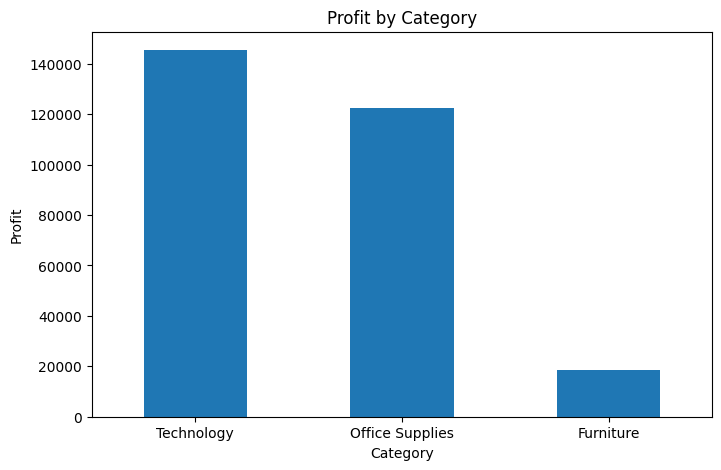

In [18]:
plt.figure(figsize=(8,5))

category_profit.plot(kind="bar")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.xticks(rotation=0)

plt.show()

In [19]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
print(region_sales)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


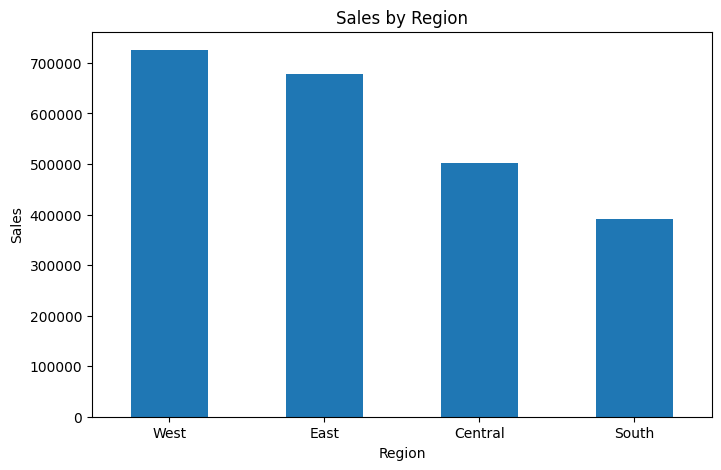

In [20]:
plt.figure(figsize=(8,5))

region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=0)

plt.show()

In [21]:
region_profit = df.groupby("Region")["Profit"].sum().sort_values(ascending=False)

print(region_profit)

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


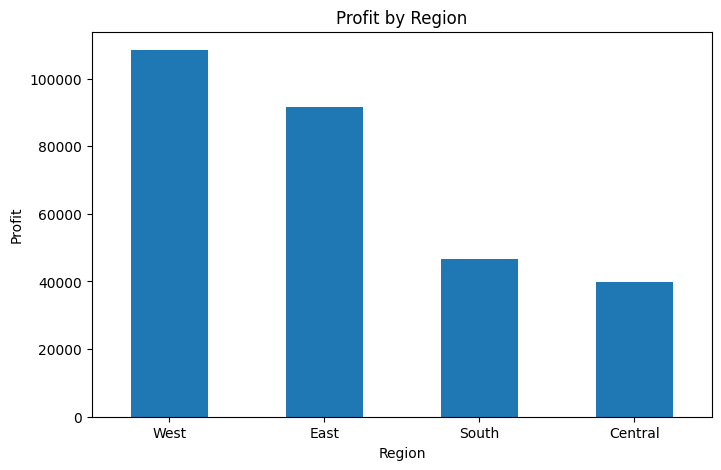

In [22]:
plt.figure(figsize=(8,5))

region_profit.plot(kind="bar")

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.xticks(rotation=0)

plt.show()

In [23]:
subcategory_sales = (
    df.groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(subcategory_sales)

Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91705.1640
Paper           78479.2060
Supplies        46673.5380
Art             27118.7920
Envelopes       16476.4020
Labels          12486.3120
Fasteners        3024.2800
Name: Sales, dtype: float64


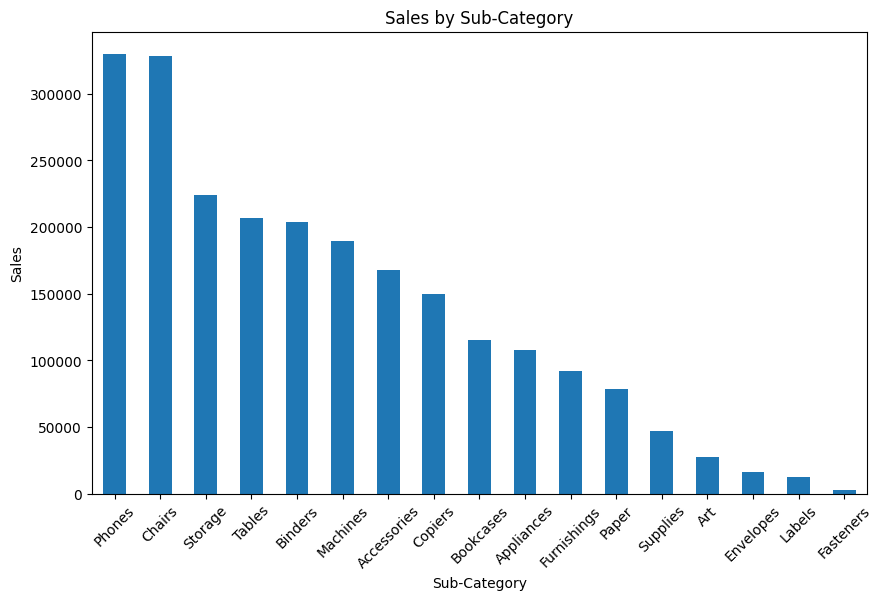

In [24]:
plt.figure(figsize=(10,6))

subcategory_sales.plot(kind="bar")

plt.title("Sales by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)

plt.show()

In [25]:
monthly_sales = df.groupby(
    ["Year", "Month"]
)["Sales"].sum().reset_index()

monthly_sales["Year_Month"] = (
    monthly_sales["Year"].astype(str)
    + "-"
    + monthly_sales["Month"].astype(str)
)

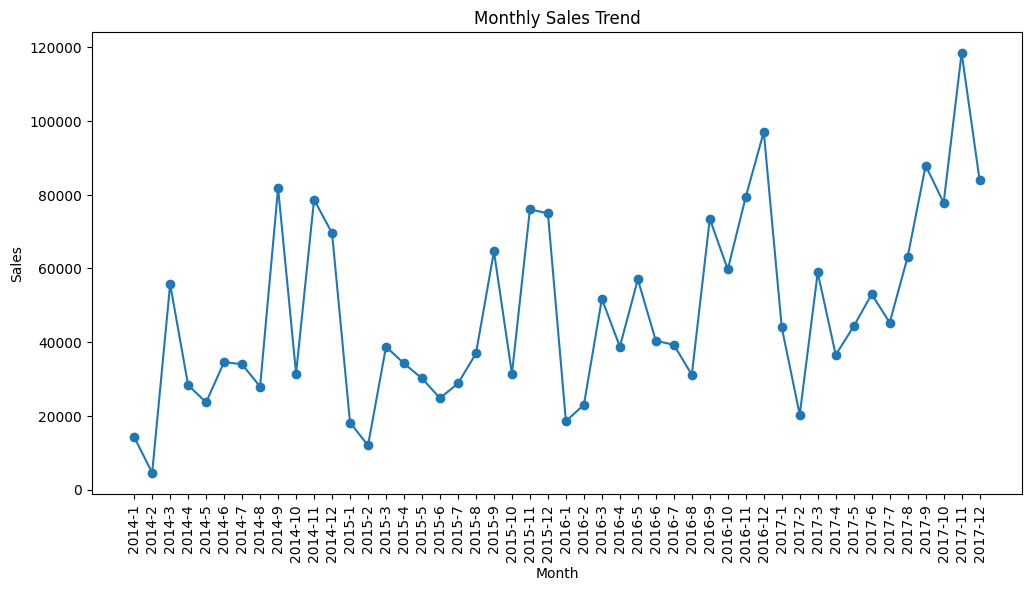

In [26]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales["Year_Month"],
    monthly_sales["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=90)

plt.show()

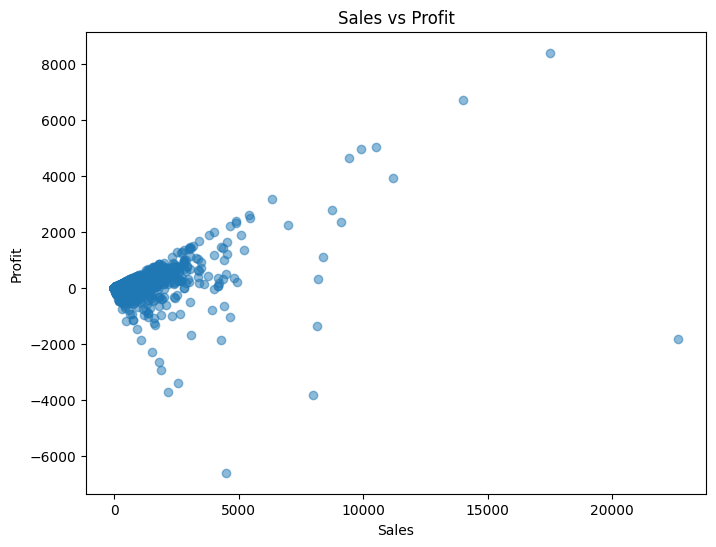

In [27]:
plt.figure(figsize=(8,6))

plt.scatter(df["Sales"], df["Profit"], alpha=0.5)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.show()

In [28]:
numeric_columns = df.select_dtypes(include=np.number)

correlation = numeric_columns.corr()

correlation

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Year,Month
Row ID,1.000000,0.009671,-0.001359,-0.004016,0.013480,0.012497,0.015430,-0.018732
Postal Code,0.009671,1.000000,-0.023854,0.012761,0.058443,-0.029961,0.004299,0.026234
Sales,-0.001359,-0.023854,1.000000,0.200795,-0.028190,0.479064,-0.009679,-0.000625
Quantity,-0.004016,0.012761,0.200795,1.000000,0.008623,0.066253,-0.005810,0.023355
Discount,0.013480,0.058443,-0.028190,0.008623,1.000000,-0.219487,-0.002662,-0.004935
Profit,0.012497,-0.029961,0.479064,0.066253,-0.219487,1.000000,0.004670,-0.000502
Year,0.015430,0.004299,-0.009679,-0.005810,-0.002662,0.004670,1.000000,-0.020183
Month,-0.018732,0.026234,-0.000625,0.023355,-0.004935,-0.000502,-0.020183,1.000000


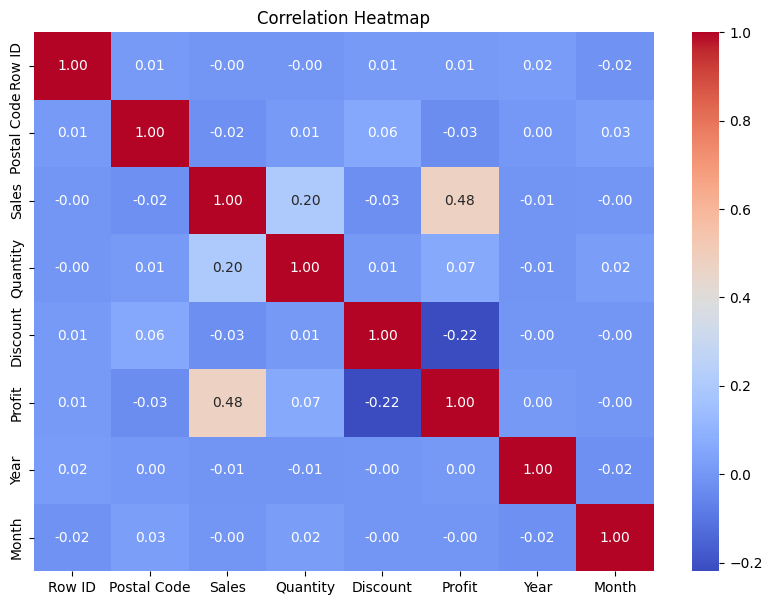

In [29]:
plt.figure(figsize=(10,7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [30]:
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


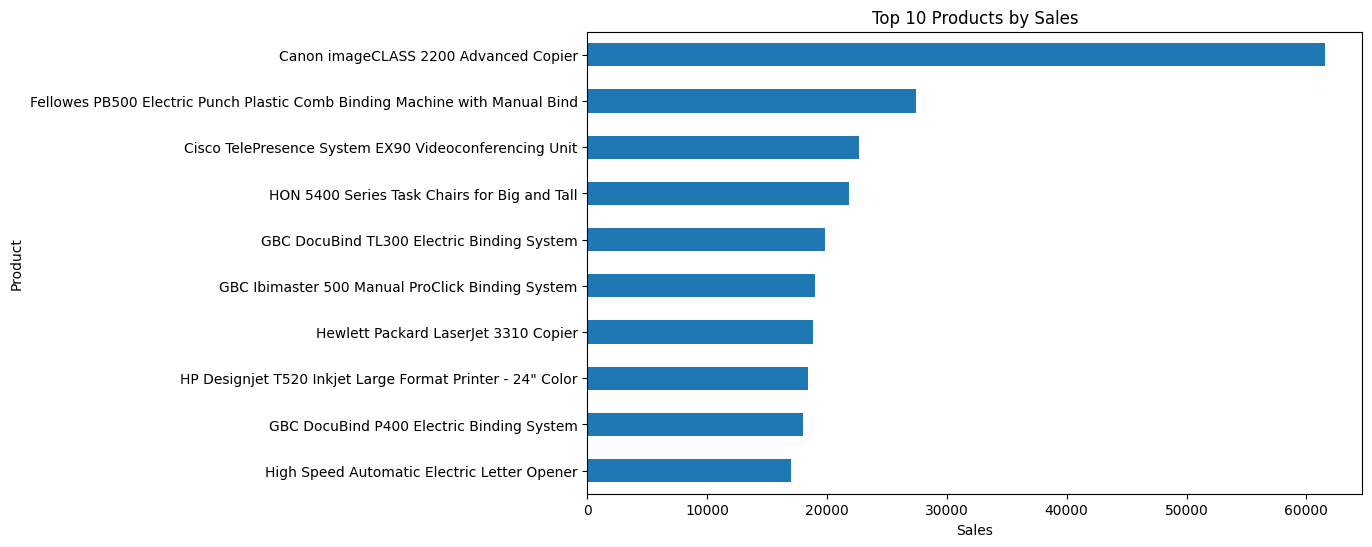

In [31]:
plt.figure(figsize=(10,6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")

plt.show()

In [32]:
top_customers = (
    df.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_customers)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


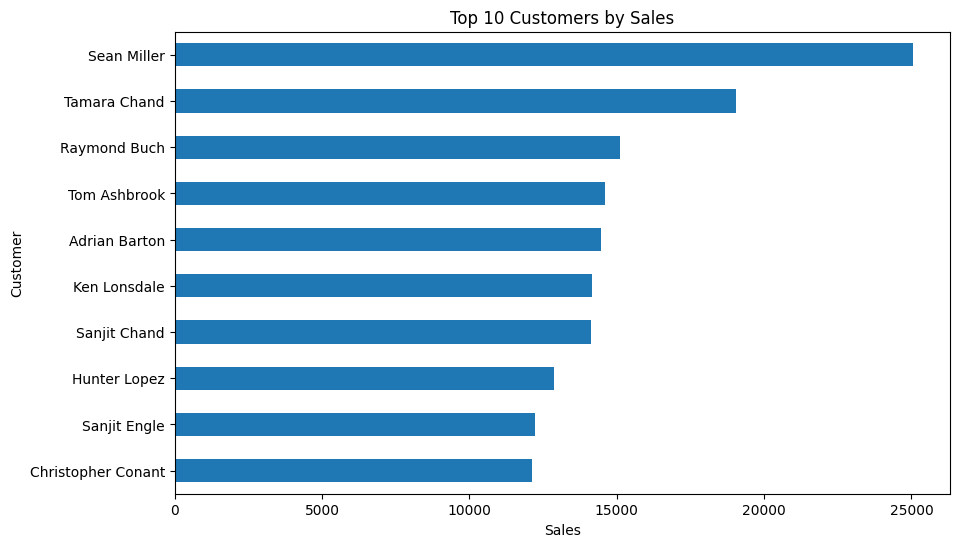

In [33]:
plt.figure(figsize=(10,6))

top_customers.sort_values().plot(kind="barh")

plt.title("Top 10 Customers by Sales")
plt.xlabel("Sales")
plt.ylabel("Customer")

plt.show()

In [34]:
yearly_data = df.groupby("Year")[["Sales", "Profit"]].sum()

print(yearly_data)

            Sales      Profit
Year                         
2014  484247.4981  49543.9741
2015  470532.5090  61618.6037
2016  609205.5980  81795.1743
2017  733215.2552  93439.2696


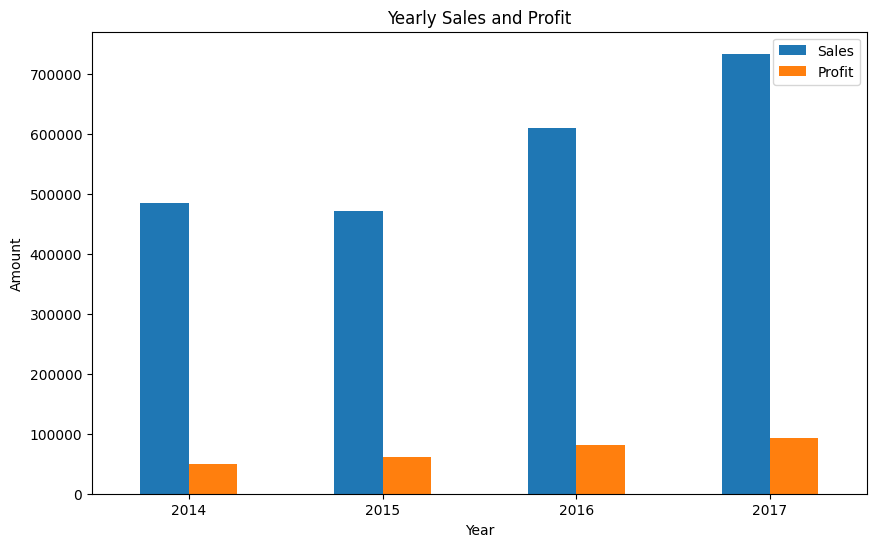

In [35]:
yearly_data.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Yearly Sales and Profit")
plt.xlabel("Year")
plt.ylabel("Amount")

plt.xticks(rotation=0)

plt.show()

In [36]:
profit_margin = (df["Profit"].sum() / df["Sales"].sum()) * 100

print("Overall Profit Margin:", round(profit_margin, 2), "%")

Overall Profit Margin: 12.47 %


In [37]:
category_summary = df.groupby("Category")[["Sales", "Profit"]].sum()

category_summary["Profit Margin (%)"] = (
    category_summary["Profit"]
    / category_summary["Sales"]
) * 100

print(category_summary)

                       Sales       Profit  Profit Margin (%)
Category                                                    
Furniture        741999.7953   18451.2728           2.486695
Office Supplies  719047.0320  122490.8008          17.035158
Technology       836154.0330  145454.9481          17.395712


In [38]:
ml_data = df[
    [
        "Sales",
        "Quantity",
        "Discount",
        "Profit"
    ]
].copy()

In [39]:
ml_data.head()

,Sales,Quantity,Discount,Profit
0,261.9600,2,0.00,41.9136
1,731.9400,3,0.00,219.5820
2,14.6200,2,0.00,6.8714
3,957.5775,5,0.45,-383.0310
4,22.3680,2,0.20,2.5164


In [40]:
X = ml_data[
    [
        "Quantity",
        "Discount",
        "Profit"
    ]
]

y = ml_data["Sales"]

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (7995, 3)
Testing data: (1999, 3)


In [42]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [43]:
y_pred = model.predict(X_test)

In [44]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 2))
print("MSE:", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 2))

MAE: 101.79
MSE: 263115.52
RMSE: 512.95
R² Score: 0.55


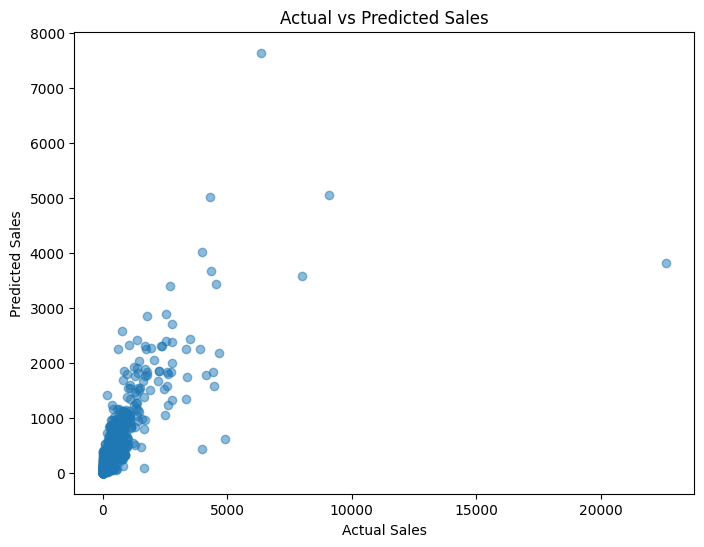

In [45]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

In [46]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

Profit      0.918805
Discount    0.046141
Quantity    0.035054
dtype: float64


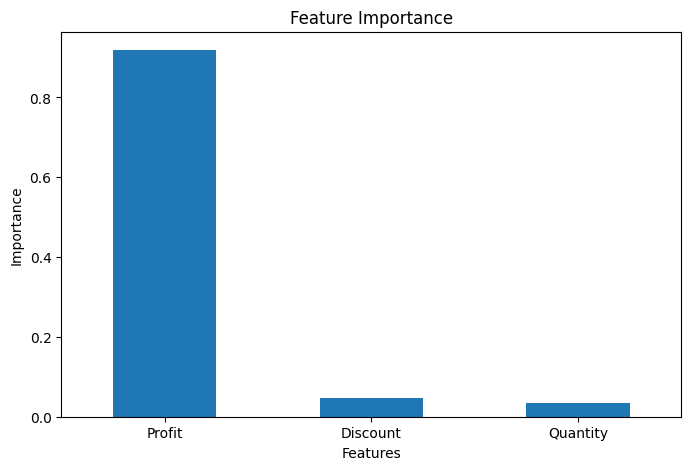

In [47]:
plt.figure(figsize=(8,5))

feature_importance.plot(kind="bar")

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=0)

plt.show()

In [48]:
best_category = category_sales.idxmax()

print("Best-selling category:", best_category)

Best-selling category: Technology


In [49]:
best_region = region_sales.idxmax()

print("Best-performing region:", best_region)

Best-performing region: West


In [50]:
best_profit_category = category_profit.idxmax()

print("Most profitable category:", best_profit_category)

Most profitable category: Technology


In [51]:
best_product = top_products.idxmax()

print("Top product by sales:", best_product)

Top product by sales: Canon imageCLASS 2200 Advanced Copier


In [52]:
best_customer = top_customers.idxmax()

print("Top customer by sales:", best_customer)

Top customer by sales: Sean Miller


## Conclusion

This project analyzed a real-world retail sales dataset to identify important sales and profit patterns.

The analysis examined sales across different categories, regions, sub-categories, customers, products, and time periods.

Key findings included:
- Identification of the highest-performing product categories.
- Comparison of sales and profit across different regions.
- Analysis of monthly and yearly sales trends.
- Identification of top-performing products and customers.
- Analysis of the relationship between sales and profit.
- Identification of important factors influencing sales.

A Random Forest Regression model was also developed to predict sales based on selected features such as quantity, discount, and profit.

Overall, the project demonstrates an end-to-end data science workflow including data preprocessing, exploratory data analysis, visualization, machine learning, model evaluation, and business insights.